<a href="https://colab.research.google.com/github/SergeiVKalinin/Probabilistic-Unmixing-0/blob/main/notebooks/01_Level_0_Known_Endmembers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Level 0: Known Endmembers

Level 0 is the simplest probabilistic unmixing problem.

The endmember spectra $S_k(E)$ are assumed to be known exactly. The uncertain quantities are the local concentrations/fractions $W_{ik}$.

$$Y_i(E) = \sum_k W_{ik}S_k(E) + \epsilon_i(E)$$

Concentration information is uncertain, while spectral uncertainty is exactly zero by assumption.

In [1]:
!pip install -q --force-reinstall --no-deps git+https://github.com/SergeiVKalinin/Probabilistic-Unmixing-0.git

import numpy as np
import matplotlib.pyplot as plt
import probunmix as pu

print("probunmix version:", pu.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
probunmix version: 0.1.0


In [2]:
data = pu.generate_example(
    n_locations=80,
    n_channels=160,
    n_library=80,
    seed=42,
)
pu.validate_data(data)

True

## Run Level 0

The public interface is intentionally small: the same `pu.fit(...)` call is used at every level.

In [3]:
result0 = pu.fit(
    data,
    level=0,
    n_draws=1000,
    seed=100,
)
print(result0.metrics)

{'reconstruction_rmse': 0.010268194496869816, 'mean_concentration_sd': 0.004960071067804328, 'concentration_rmse': 0.004808932038814083, 'spectral_rmse': 0.0}


## Inspect the result

Every level returns an `UnmixingResult` with the same core fields:

- `W_mean`, `W_sd`: posterior concentration summaries;
- `S_mean`, `S_sd`: posterior endmember summaries;
- `Y_pred`: reconstructed spectra;
- `residuals`: measured minus reconstructed spectra.

At Level 0, `S_sd` must be zero because the spectra are treated as exact.

Maximum spectral SD: 0.0
Maximum concentration closure error: 1.7763568394002505e-15


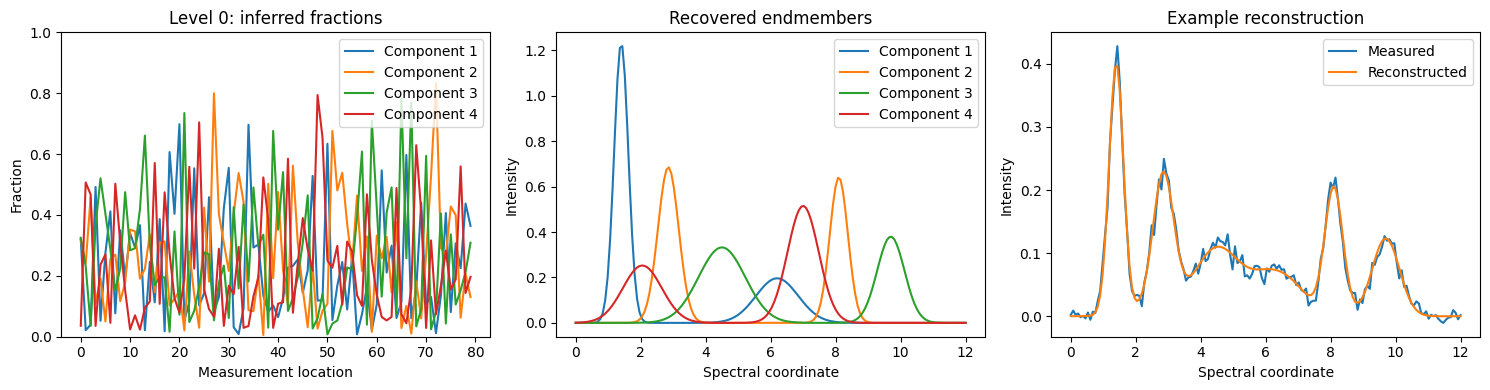

In [4]:
print("Maximum spectral SD:", result0.S_sd.max())
print("Maximum concentration closure error:",
      np.abs(result0.W_mean.sum(axis=1) - 1).max())

pu.plot_result(data, result0);

## Synthetic evaluation

Because this is a benchmark, the package can compare the inferred fractions with hidden truth. These truth-based metrics are evaluation diagnostics only; they are not available for real experimental data.

In [5]:
for k in range(data.n_components):
    rmse = np.sqrt(np.mean((result0.W_mean[:, k] - data.W_true[:, k])**2))
    print(
        f"Component {k+1}: concentration RMSE = {rmse:.5f}, "
        f"mean posterior SD = {result0.W_sd[:, k].mean():.5f}"
    )

Component 1: concentration RMSE = 0.00471, mean posterior SD = 0.00480
Component 2: concentration RMSE = 0.00402, mean posterior SD = 0.00468
Component 3: concentration RMSE = 0.00432, mean posterior SD = 0.00456
Component 4: concentration RMSE = 0.00596, mean posterior SD = 0.00579


**Takeaway:** Level 0 isolates uncertainty in the mixing fractions. It is the reference case for asking what changes when spectral knowledge is relaxed.